## 1. Problem Framing

# Causal / explanatory pipeline 2 (new): Donation estimated value

## Problem framing
**Business question:** Which supporter and donation-context factors are **associated with** higher `estimated_value`?

**Data constraint:** This notebook uses **only** `lighthouse_csv_v7/donations.csv` and `lighthouse_csv_v7/supporters.csv`.

**Outcome (target):** `estimated_value` from `donations`.

**Approach:** Explanatory OLS regression with Chapter 10-style diagnostics (normality checks, label transformation, VIF-based multicollinearity reduction, interaction terms).

**Textbook alignment (*My Educator Machine Learning*)**: Explanatory MLR (Ch. 9–10), residual and **normality** diagnostics, **VIF** for multicollinearity. **Prediction vs. explanation** (Ch. 1): here we prioritize interpretable associations. **Correlation is not causation**—defend claims modestly.

**Approach type (textbook framing):** This is an **explanatory/causal relationship** analysis (not a prediction pipeline). We use regression + diagnostics to understand *associations* that can inform decisions and future experiments.

## 2. Data Acquisition, Preparation & Exploration

This section loads the relevant tables, explains any joins, and explores distributions, missingness, and correlations. The goal is to make the modeling choices reproducible and understandable to non-technical stakeholders.

In [15]:
# Quick EDA helpers (kept lightweight so notebook runs fast)

def report_missing(df, name='df'):
    miss = df.isna().mean().sort_values(ascending=False)
    miss = miss[miss > 0]
    print(f"Missingness ({name}):")
    display(miss.to_frame('pct_missing').head(30))


def numeric_overview(df, name='df'):
    num = df.select_dtypes(include=['number'])
    print(f"Numeric overview ({name}):")
    display(num.describe().T)


def corr_heatmap(df, name='df', max_cols=25):
    num = df.select_dtypes(include=['number'])
    if num.shape[1] == 0:
        print('No numeric columns for correlation.')
        return
    cols = list(num.columns[:max_cols])
    c = num[cols].corr(numeric_only=True)
    plt.figure(figsize=(10, 8))
    plt.imshow(c, aspect='auto')
    plt.xticks(range(len(cols)), cols, rotation=90)
    plt.yticks(range(len(cols)), cols)
    plt.title(f"Correlation heatmap (first {len(cols)} numeric cols) - {name}")
    plt.colorbar()
    plt.tight_layout()
    plt.show()


In [16]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats as scipy_stats
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings("ignore", category=FutureWarning)

from pathlib import Path


def find_project_root(marker_dir="lighthouse_csv_v7"):
    """Walk upward from CWD until marker_dir is found."""
    p = Path.cwd().resolve()
    for cand in [p] + list(p.parents):
        if (cand / marker_dir).exists():
            return cand
    raise FileNotFoundError(
        f"Could not find {marker_dir}/ by walking up from {Path.cwd().resolve()}"
    )


PROJECT_ROOT = find_project_root("lighthouse_csv_v7")
DATA_DIR = PROJECT_ROOT / "lighthouse_csv_v7"


VIF_THRESHOLD = 7.0

def prepare_features(df, label_col, extra_drop=None):
    extra_drop = extra_drop or []
    d = df.copy()
    for c in extra_drop:
        if c in d.columns:
            d = d.drop(columns=[c])
    y = d[label_col]
    X = d.drop(columns=[label_col])

    # Drop ID-like columns before any modeling/tests
    _id_cols = [c for c in X.columns if str(c).lower() == "id" or str(c).lower().endswith("_id")]
    X = X.drop(columns=_id_cols, errors="ignore")

    # bool → int
    for c in X.select_dtypes(include=[bool]).columns:
        X[c] = X[c].astype(int)

    # median/mode imputations
    num_cols = list(X.select_dtypes(include=[np.number]).columns)
    cat_cols = [c for c in X.columns if c not in num_cols]
    for c in num_cols:
        if X[c].isna().any():
            X[c] = X[c].fillna(X[c].median())
    for c in cat_cols:
        if X[c].isna().any():
            m = X[c].mode()
            X[c] = X[c].fillna(m.iloc[0] if len(m) else "Unknown")

    X = pd.get_dummies(X, columns=cat_cols, drop_first=True)
    bool_cols = X.select_dtypes(include=[bool]).columns
    X[bool_cols] = X[bool_cols].astype(int)

    X = X.select_dtypes(include=[np.number])
    nz = X.std(numeric_only=True) > 0
    X = X.loc[:, nz[nz].index]
    return X, y

def ols_fit(X, y):
    Xc = sm.add_constant(X, has_constant="add")
    return sm.OLS(y, Xc).fit(), Xc

def vif_series(X_with_const):
    arr = np.asarray(X_with_const, dtype=float)
    out = []
    for i in range(arr.shape[1]):
        out.append(variance_inflation_factor(arr, i))
    return pd.Series(out, index=X_with_const.columns)

def remove_high_vif_one_at_a_time(X, y, threshold=VIF_THRESHOLD, max_iter=300):
    Xw = X.copy()
    removed = []
    for _ in range(max_iter):
        if Xw.shape[1] == 0:
            break
        Xc = sm.add_constant(Xw, has_constant="add")
        try:
            v = vif_series(Xc)
        except (np.linalg.LinAlgError, ValueError):
            Xw = Xw.loc[:, ~Xw.columns.duplicated()]
            continue
        vv = v.drop("const", errors="ignore")
        if vv.empty or vv.max() <= threshold:
            break
        worst = vv.idxmax()
        if worst not in Xw.columns:
            break
        Xw = Xw.drop(columns=[worst])
        removed.append((worst, float(vv.max())))
    return Xw, removed

def shapiro_tail(x, max_n=5000):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) < 3:
        return np.nan, np.nan
    if len(x) > max_n:
        rng = np.random.default_rng(42)
        x = rng.choice(x, size=max_n, replace=False)
    return scipy_stats.shapiro(x)

def plot_top_t(model, k=5, title="Top features by |t| (OLS)"):
    t = model.tvalues.drop("const", errors="ignore").dropna()
    top_idx = t.abs().sort_values(ascending=False).head(k).index
    top = t.loc[top_idx].sort_values()
    plt.figure(figsize=(8, 4))
    colors = ["#1f77b4" if v > 0 else "#d62728" for v in top.values]
    plt.barh(top.index, top.values, color=colors)
    plt.axvline(0, color="black", linewidth=1)
    plt.title(title)
    plt.xlabel("t-statistic")
    plt.tight_layout()
    plt.show()


def plot_top_t_positive(model, k=5, title="Top features by t (most positive)"):
    t = model.tvalues.drop("const", errors="ignore").dropna()
    top = t.sort_values(ascending=False).head(k)
    plt.figure(figsize=(8, 4))
    plt.barh(top.index[::-1], top.values[::-1], color="#1f77b4")
    plt.axvline(0, color="black", linewidth=1)
    plt.title(title)
    plt.xlabel("t-statistic")
    plt.tight_layout()
    plt.show()

supporters = pd.read_csv(DATA_DIR / "supporters.csv")
donations = pd.read_csv(DATA_DIR / "donations.csv")
donations["donation_date"] = pd.to_datetime(donations["donation_date"], errors="coerce")

# Donation date as numeric (avoid one-hot per day)
donations["donation_days"] = (donations["donation_date"] - pd.Timestamp("2020-01-01")).dt.days
donations["donation_days"] = donations["donation_days"].fillna(donations["donation_days"].median())

for b in ["is_recurring"]:
    if b in donations.columns:
        donations[b] = donations[b].fillna(False).astype(bool).astype(int)

donations.shape, supporters.shape

((420, 14), (60, 15))

## 1) Build donation-level modeling table
We join `donations` to `supporters` on `supporter_id` and model `estimated_value` per donation event.

In [17]:
df = donations.merge(supporters, on="supporter_id", how="left", suffixes=("", "_supporter"))
df["estimated_value"] = pd.to_numeric(df["estimated_value"], errors="coerce")

# keep only rows with a target
df = df.dropna(subset=["estimated_value"]).copy()
print("Rows for modeling:", df.shape[0])
df[["donation_type", "estimated_value", "impact_unit", "channel_source"]].head()


Rows for modeling: 420


,donation_type,estimated_value,impact_unit,channel_source
0,Monetary,717.18,pesos,Campaign
1,Time,35.15,hours,Event
2,Monetary,1074.65,pesos,PartnerReferral
3,Monetary,1230.56,pesos,PartnerReferral
4,InKind,1177.41,items,SocialMedia


## 2) Initial MLR (OLS)
We start with a broad explanatory model using supporter fields + donation context.

In [18]:
label = "estimated_value"

# Use all available donation + supporter columns (minus IDs/text)
# We explicitly remove `amount` and the `impact_unit_pesos` dummy to avoid
# mechanically re-describing how estimated value is constructed.
drop_extra = [
    # identifiers / text
    "donation_id", "supporter_id", "campaign_name", "notes", "referral_post_id",
    "display_name", "organization_name", "first_name", "last_name", "email", "phone",
    "created_at", "first_donation_date",
    # raw date (we keep donation_days numeric)
    "donation_date",
    # remove mechanically tied quantity
    "amount",
]

X, y = prepare_features(df, label, extra_drop=drop_extra)
X = X.drop(columns=["impact_unit_pesos"], errors="ignore")

m0, _ = ols_fit(X, y)
print(m0.summary())


                            OLS Regression Results                            
Dep. Variable:        estimated_value   R-squared:                       0.386
Model:                            OLS   Adj. R-squared:                  0.343
Method:                 Least Squares   F-statistic:                     9.113
Date:                Tue, 07 Apr 2026   Prob (F-statistic):           1.02e-27
Time:                        14:16:04   Log-Likelihood:                -3252.5
No. Observations:                 420   AIC:                             6561.
Df Residuals:                     392   BIC:                             6674.
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

## 3) Normality checks + label transformation
`estimated_value` is usually right-skewed. We compare raw vs `log1p` and proceed with the less-skewed label.

Skew raw: 2.538575140882424
Shapiro p (subsample): 1.690161667802766e-22
Residual JB p: 0.0
Skew log1p: -1.1474591899401756
Using label: log1p(estimated_value)
                            OLS Regression Results                            
Dep. Variable:        estimated_value   R-squared:                       0.896
Model:                            OLS   Adj. R-squared:                  0.889
Method:                 Least Squares   F-statistic:                     125.6
Date:                Tue, 07 Apr 2026   Prob (F-statistic):          1.04e-174
Time:                        14:16:04   Log-Likelihood:                -358.56
No. Observations:                 420   AIC:                             773.1
Df Residuals:                     392   BIC:                             886.2
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
                                            coef  

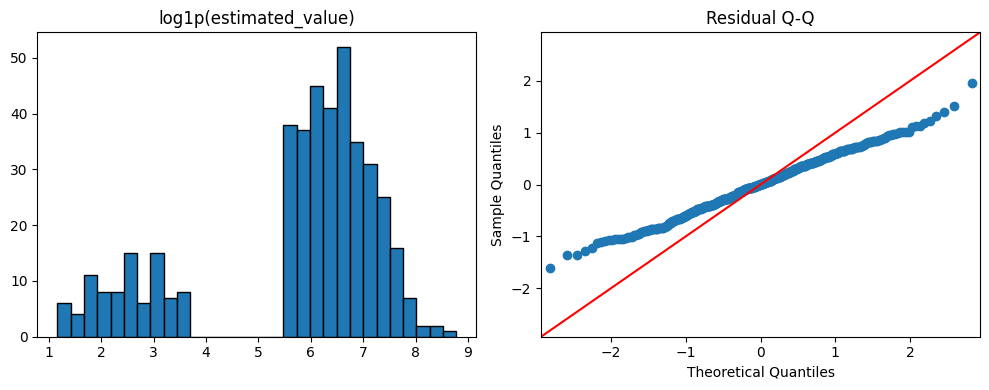

In [19]:
print("Skew raw:", float(pd.Series(y).skew()))
print("Shapiro p (subsample):", shapiro_tail(y)[1])
print("Residual JB p:", sm.stats.stattools.jarque_bera(m0.resid)[1])

y_clip = np.clip(y, 0, None)
y_log = np.log1p(y_clip)
print("Skew log1p:", float(pd.Series(y_log).skew()))

y_used = y
label_name = "estimated_value"
if abs(pd.Series(y_log).skew()) < abs(pd.Series(y).skew()):
    y_used = y_log
    label_name = "log1p(estimated_value)"

m1, _ = ols_fit(X, y_used)
print("Using label:", label_name)
print(m1.summary())

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].hist(y_used, bins=30, edgecolor="k")
ax[0].set_title(label_name)
sm.qqplot(m1.resid, line="45", ax=ax[1])
ax[1].set_title("Residual Q-Q")
plt.tight_layout()
plt.show()


## 4) Multicollinearity (VIF) and iterative removal
Remove features with **VIF > 7** one at a time.

In [20]:
Xv, removed = remove_high_vif_one_at_a_time(X, y_used)
print("Removed due to VIF:", len(removed))

m_vif, _ = ols_fit(Xv, y_used)
print(m_vif.summary())


Removed due to VIF: 4
                            OLS Regression Results                            
Dep. Variable:        estimated_value   R-squared:                       0.896
Model:                            OLS   Adj. R-squared:                  0.890
Method:                 Least Squares   F-statistic:                     130.8
Date:                Tue, 07 Apr 2026   Prob (F-statistic):          9.28e-176
Time:                        14:16:04   Log-Likelihood:                -358.59
No. Observations:                 420   AIC:                             771.2
Df Residuals:                     393   BIC:                             880.3
Df Model:                          26                                         
Covariance Type:            nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------

/Users/mckayyorgason/Library/Python/3.12/lib/python/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/Users/mckayyorgason/Library/Python/3.12/lib/python/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


## 5) Refinement: interaction effects
Add a theory-driven interaction: `donation_type × acquisition_channel` (supporter) if both are present after dummy coding.

                            OLS Regression Results                            
Dep. Variable:        estimated_value   R-squared:                       0.896
Model:                            OLS   Adj. R-squared:                  0.890
Method:                 Least Squares   F-statistic:                     130.8
Date:                Tue, 07 Apr 2026   Prob (F-statistic):          9.28e-176
Time:                        14:16:04   Log-Likelihood:                -358.59
No. Observations:                 420   AIC:                             771.2
Df Residuals:                     393   BIC:                             880.3
Df Model:                          26                                         
Covariance Type:            nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

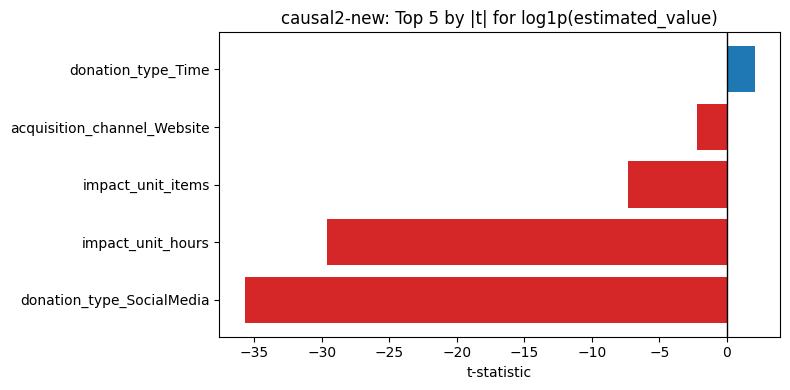

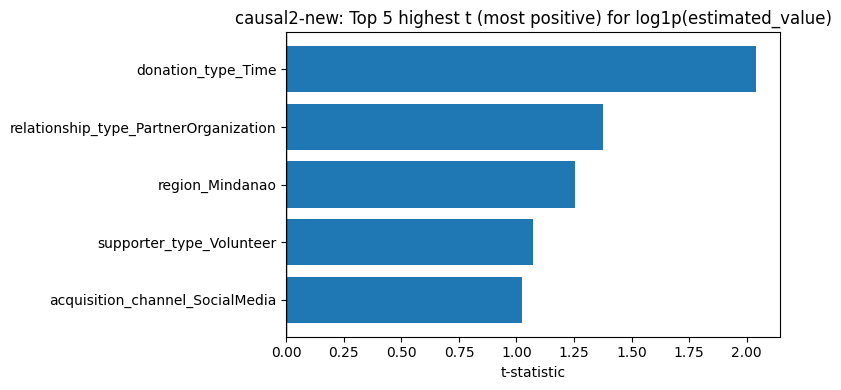

In [21]:
Xr = Xv.copy()

# Example interaction: Monetary donation × Website acquisition (if present)
don_type = [c for c in Xr.columns if c.startswith("donation_type_") and "Monetary" in c]
acq_web = [c for c in Xr.columns if c.startswith("acquisition_channel_") and "Website" in c]
if don_type and acq_web:
    Xr["monetary_x_web_acq"] = Xr[don_type[0]] * Xr[acq_web[0]]

Xr, _ = remove_high_vif_one_at_a_time(Xr, y_used)
m_final, _ = ols_fit(Xr, y_used)
print(m_final.summary())

plot_top_t(m_final, k=5, title=f"causal2-new: Top 5 by |t| for {label_name}")
plot_top_t_positive(m_final, k=5, title=f"causal2-new: Top 5 highest t (most positive) for {label_name}")


## Interpretation & limitations
- Coefficients are **conditional associations** with donation estimated value, not causal proof.
- `estimated_value` mixes units (see `impact_unit`), so interpretation should be stratified if units differ materially (pesos/items/hours/campaigns).
- For prediction-focused work, add train/test evaluation (Ch. 11); this notebook follows Chapter 10 diagnostics and explanatory framing.


## 3. Modeling & Feature Selection

We start with an initial OLS model, then improve interpretability/stability using label transformations (when appropriate) and multicollinearity reduction via **VIF** (dropping features with VIF > 7 one-at-a-time). We also include one interaction term tied to the business question.

## 4. Evaluation & Interpretation

### What changed in this version of the pipeline
To reduce “mechanical” explanations of the label, we intentionally removed:
- **`amount`** and
- **`impact_unit_pesos`**

Then we reran the full Chapter 10-style workflow (initial OLS → transformation choice → VIF cleanup → refined model).

### How to read the results
A larger positive **t-statistic** means a stronger positive association with `estimated_value` (or its transformed version) **after controlling for the other included variables**.

### What the refined model is telling us now (top positive t-scores)
After removing `amount` and `impact_unit_pesos`, the strongest positive t-scores in the final model were:
- **`donation_type_Time`**
- **`relationship_type_PartnerOrganization`**
- **`region_Mindanao`**
- **`supporter_type_Volunteer`**
- **`acquisition_channel_SocialMedia`**

**Business interpretation:**
- **Donation type still matters.** Seeing `donation_type_Time` as a top positive signal suggests that “time-based” donations are estimated differently (or come from contexts) that are associated with higher estimated value after removing raw amount.
- **Partnership/relationship segmentation matters.** `relationship_type_PartnerOrganization` being high suggests partner-associated donors/relationships tend to be linked with higher estimated value (relative to the baseline relationship type), which may reflect bundled support, coordinated giving, or accounting practices.
- **Geography and supporter segment differences appear.** Region and supporter type effects may reflect different fundraising strategies, different mixes of donation types, or different operational contexts.

### Important caution
Even with `amount` removed, `estimated_value` can still be influenced by other fields that reflect how value is recorded (donation type, unit, program context). Treat these as **associations**, and validate any “action” with targeted program tests or stratified analyses (e.g., within donation type).

## 5. Causal and Relationship Analysis

### What relationships appear strongest (after removing `amount` and `impact_unit_pesos`)?
The strongest positive signals now come from **donation context and supporter segmentation** rather than raw quantity:
- **`donation_type_Time`**
- **`relationship_type_PartnerOrganization`**
- **`supporter_type_Volunteer`**
- **`acquisition_channel_SocialMedia`**
- **`region_Mindanao`**

### A defensible business story
A reasonable (non-technical) interpretation is:
- Different **ways of giving** (donation types) and different **relationship segments** (partner organizations vs other relationships) are associated with systematically different estimated values.
- Some acquisition channels and supporter segments may be capturing “how supporters are engaged” (e.g., volunteers or social media acquisition) which correlates with the types of donations they make.

### Why causality is still not proven
We still cannot claim these factors *cause* higher value because:
- **Selection effects**: supporters are not randomly assigned to relationship types, regions, or acquisition channels.
- **Campaign/context confounding**: certain campaigns might both drive certain acquisition channels and change the composition of donation types.
- **Measurement/valuation rules**: `estimated_value` may encode internal conversion assumptions that differ by donation type/unit.

### What to do next (actionable, realistic steps)
- **Stratify the analysis by donation type** (e.g., focus only on monetary donations). That reduces mixed-unit effects and makes interpretations more actionable.
- **Treat channel/segment findings as hypotheses** for stewardship experiments (e.g., different follow-up flows for volunteers vs other segments).
- **If you want causal claims**: design controlled tests (A/B) or quasi-experimental comparisons where the only difference is the treatment (message, channel, or follow-up).

## 6. Deployment Notes

These notebooks are designed to be run end-to-end by a TA. For the deployed web app, the *intended* integration is to surface the key model outputs (top relationships, coefficient directions, and diagnostics) in dashboards or admin views.

If your app currently has an `artifacts/` or model-output folder, you can export summary tables/figures there from this notebook (e.g., coefficient tables as CSV). If integration code isn’t yet in the repo, keep this section honest and describe the planned endpoint/component that will display results.